# Task 07 - Model Evaluation
Evaluate GCN and GAT using accuracy, weighted precision, recall, and F1.

C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


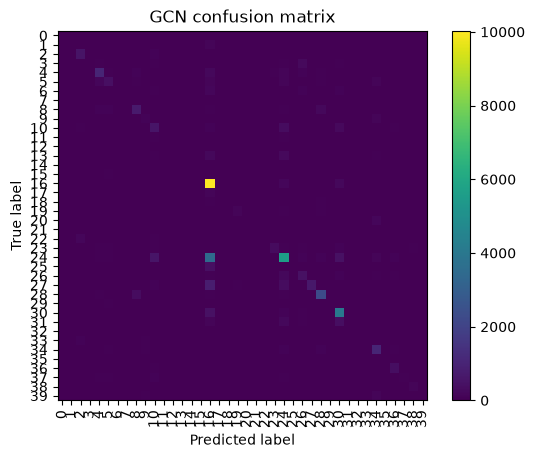

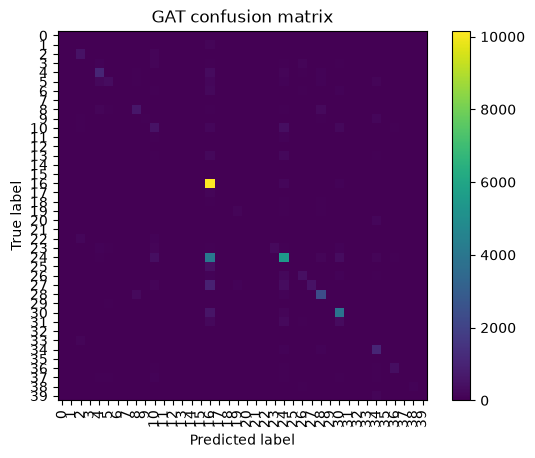

,model,split,accuracy,precision_weighted,recall_weighted,f1_weighted
0,GCN,test,0.586404,0.549157,0.586404,0.53885
1,GAT,test,0.573936,0.541439,0.573936,0.52195


In [1]:
import sys
from pathlib import Path

# Make the project root importable when running locally
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from src.config import RAW_DATA_DIR, MODELS_DIR
from src.data import load_ogbn_arxiv
from src.models import GCN, GAT
from src.evaluation import evaluate_model
from src.evaluation.comparison import plot_model_comparison

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset, data, split_idx = load_ogbn_arxiv(RAW_DATA_DIR)
data = data.to(device)
split_idx = {k: v.to(device) for k, v in split_idx.items()}

models = {
    'GCN': GCN(data.num_features, 256, dataset.num_classes),
    'GAT': GAT(data.num_features, 64, dataset.num_classes, heads=4)
}

out = PROJECT_ROOT / 'results' / 'evaluation'
out.mkdir(parents=True, exist_ok=True)

rows = []
for name, model in models.items():
    ckpt = MODELS_DIR / f'best_{name.lower()}.pt'
    if not ckpt.exists():
        print(f'[SKIP] Checkpoint not found: {ckpt} — run notebook 04/05 first.')
        continue
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.to(device)
    metrics, y_true, y_pred = evaluate_model(model, data, split_idx['test'], 'test')
    rows.append({'model': name, **metrics})
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, xticks_rotation='vertical', include_values=False
    )
    plt.title(f'{name} confusion matrix')
    plt.savefig(out / f'confusion_matrix_{name.lower()}.png', dpi=180, bbox_inches='tight')
    plt.show()

if rows:
    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(out / 'metrics.csv', index=False)
    plot_model_comparison(metrics_df, out / 'model_comparison.png')
    display(metrics_df)
else:
    print('No model checkpoints found. Run notebooks 04 and 05 first.')
